In [1]:
import os
from os.path import join
import numpy as np
import torch
import matplotlib.pyplot as plt
import uncertainty_toolbox as uct

RESULT_ROOT_PATH = join('..', 'results', 'uncertainty_error_calculation')

In [2]:
def plot_diff_uncertainties(uncertainties_, preds_, refs_):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for i, uncertainty_name in enumerate(uncertainties_.keys()):
        if uncertainty_name == 'GPR model':
            title = 'GPR standard deviation'
            uncertainties__ = torch.sqrt(uncertainties_[uncertainty_name]).numpy()
        else:
            uncertainties__ = uncertainties_[uncertainty_name].numpy()
            title = uncertainty_name

        uct.viz.plot_calibration(preds_ * 1000, uncertainties__ * 1000, refs_ * 1000, ax=axes[i])

        axes[i].xaxis.set_tick_params(labelsize=14)
        axes[i].yaxis.set_tick_params(labelsize=14)
        
        axes[i].set_xlabel('Predicted proportion', fontsize=14)
        if i == 0:
            axes[i].set_ylabel('Observed proportion', fontsize=14)
        else:
            axes[i].set_ylabel('')

        for text in axes[i].texts:
            if "Miscalibration area" in text.get_text():
                text.set_fontsize(14)

        axes[i].set_title(title, fontsize=16)


# Benzene

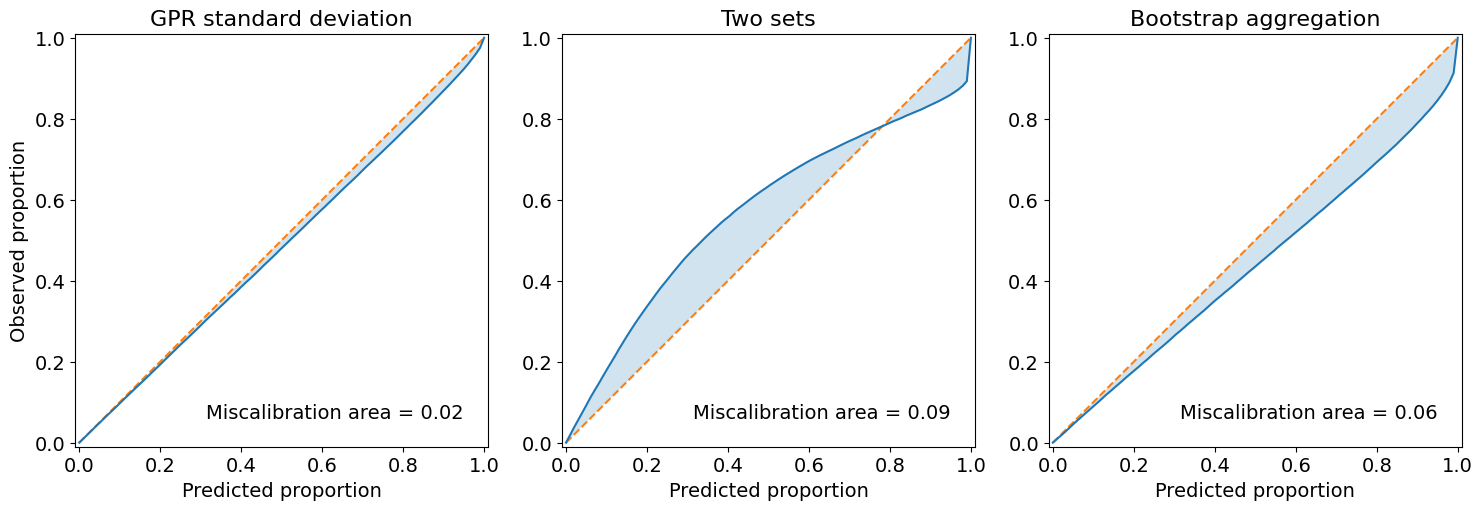

In [3]:
result_path = join(RESULT_ROOT_PATH, 'rmd17', 'benzene', 'GPR_soap_atomistic_atomistic_sum1')
refs = torch.load(join(result_path, 'refs'), weights_only=True).numpy()
errors = torch.load(join(result_path, 'errors'), weights_only=True)['GPR model'].numpy()
preds = errors + refs
uncertainties = torch.load(join(result_path, 'uncertainties'), weights_only=True)

plot_diff_uncertainties(uncertainties, preds, refs)
plt.tight_layout()

# SMA

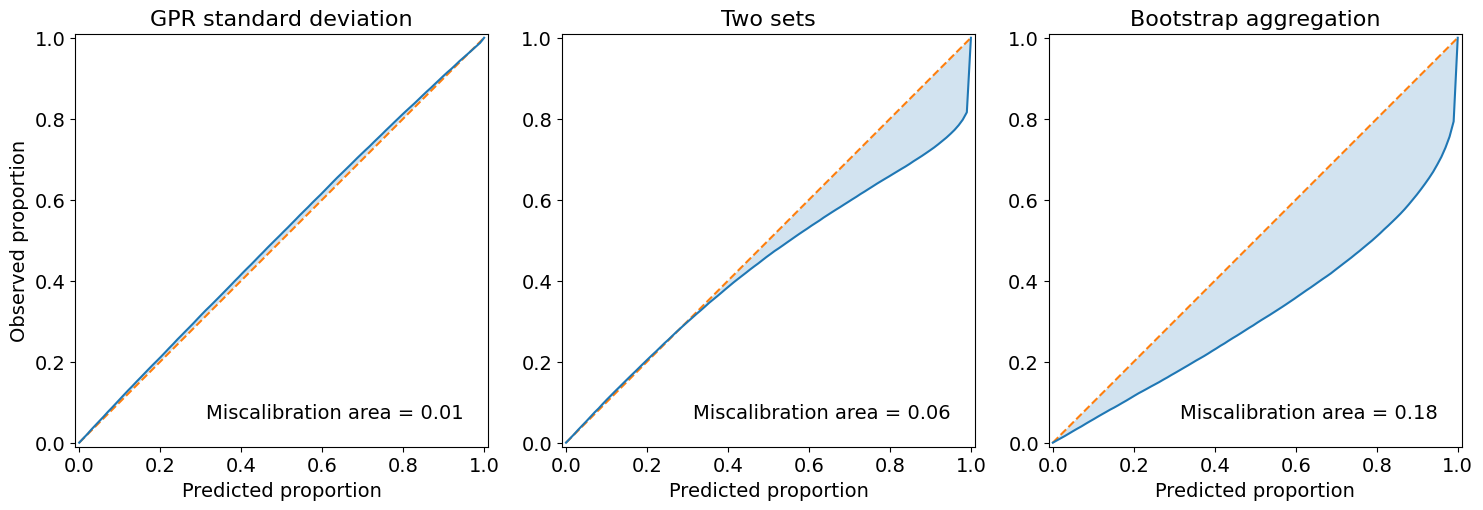

In [4]:
result_path = join(RESULT_ROOT_PATH, 'ws22', 'ws22_sma', 'GPR_soap_atomistic_atomistic_sum1')
refs = torch.load(join(result_path, 'refs'), weights_only=True).numpy()
errors = torch.load(join(result_path, 'errors'), weights_only=True)['GPR model'].numpy()
preds = errors + refs
uncertainties = torch.load(join(result_path, 'uncertainties'), weights_only=True)

plot_diff_uncertainties(uncertainties, preds, refs)
plt.tight_layout()